<a href="https://colab.research.google.com/github/Chase-Troy/Course-Assignments/blob/main/Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the necessary Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

Setting style for better plots

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Load the Iris Dataset

In [3]:
iris = load_iris()

# Spliting the data into features (X) and target labels (y)
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Dataset details
print("📊 IRIS DATASET INFORMATION:")
print("-" * 40)
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")
print(f"Number of each species: {np.bincount(y)}")
print(f"Classes: {iris.target_names}")
print()

📊 IRIS DATASET INFORMATION:
----------------------------------------
Number of samples: 150
Number of features: 4
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Number of each species: [50 50 50]
Classes: ['setosa' 'versicolor' 'virginica']



Data Exploration

In [4]:
# Creating DataFrame for better visualization
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['species'] = y
iris_df['species_name'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

In [5]:
# Displing basic statistics
print("Few rows of the dataset:")
print(iris_df.head())

Few rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


In [6]:
print(iris_df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


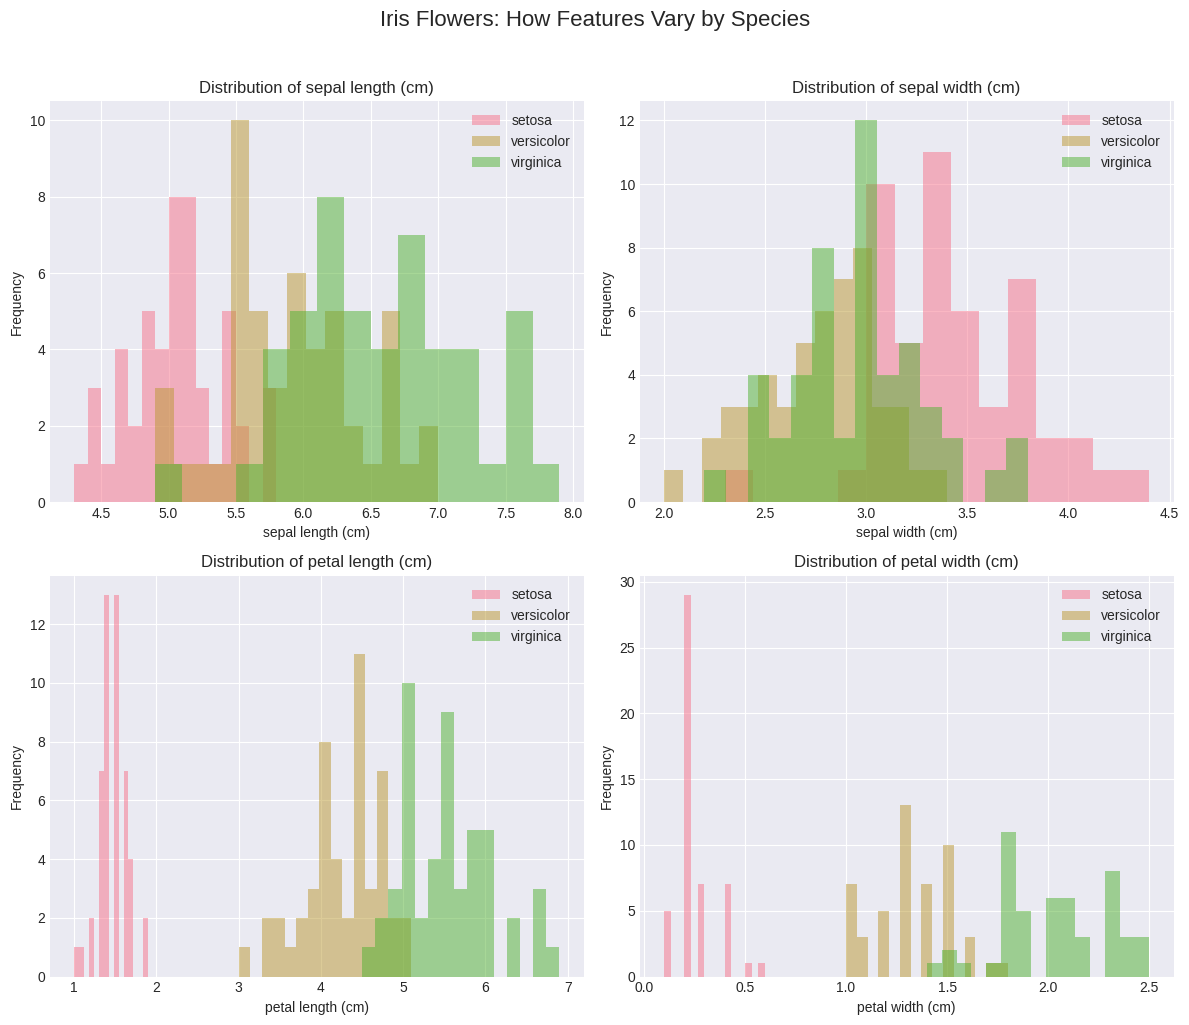

In [7]:
# Visualizing the dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Iris Flowers: How Features Vary by Species', fontsize=16, y=1.02)

features = feature_names
colors = ['skyblue', 'lightgreen', 'salmon']
for idx, feature in enumerate(features):
    ax = axes[idx//2, idx%2]
    for species in [0, 1, 2]:
        species_data = iris_df[iris_df['species'] == species][feature]
        ax.hist(species_data, alpha=0.5, label=target_names[species], bins=15)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

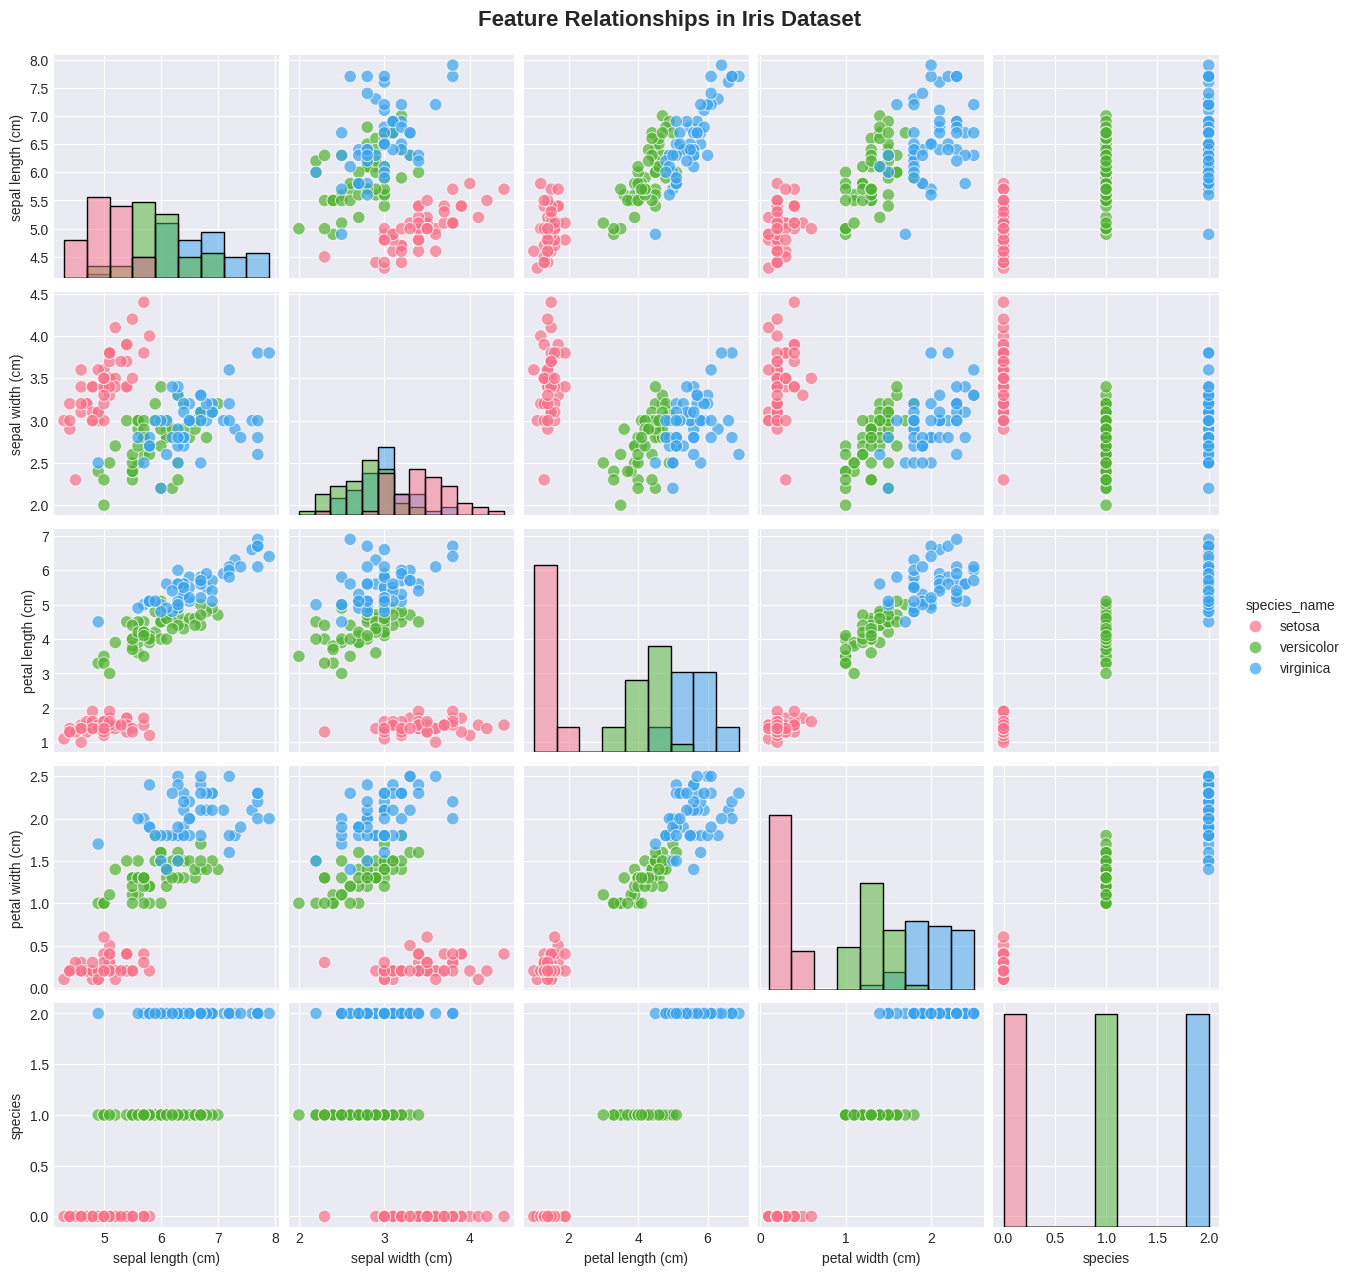

In [8]:
# Creating pair plot to see relationships between features
plt.figure(figsize=(12, 10))

# Using seaborn's pairplot for quick visualization
sns.pairplot(iris_df,
             hue='species_name',
             diag_kind='hist',
             palette='husl',
             plot_kws={'alpha': 0.7, 's': 80})

plt.suptitle('Feature Relationships in Iris Dataset',
             y=1.02,
             fontsize=16,
             fontweight='bold')

plt.show()

Hyperparameter Tuning with Cross-Validation (cv=10)

In [9]:
# Standardize features for better KNN performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Performing cross-validation for k values from 1 to 30
k_range = range(1, 31)
cv_scores = []
cv_scores_std = []

print("Performing 10-fold cross-validation for k = 1 to 30...")
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())
    cv_scores_std.append(scores.std())
    if k in [1, 5, 10, 15, 20, 25, 30]:
        print(f"k={k}: Mean Accuracy = {scores.mean():.4f} (±{scores.std():.4f})")

Performing 10-fold cross-validation for k = 1 to 30...
k=1: Mean Accuracy = 0.9533 (±0.0670)
k=5: Mean Accuracy = 0.9533 (±0.0521)
k=10: Mean Accuracy = 0.9600 (±0.0327)
k=15: Mean Accuracy = 0.9600 (±0.0442)
k=20: Mean Accuracy = 0.9467 (±0.0653)
k=25: Mean Accuracy = 0.9467 (±0.0499)
k=30: Mean Accuracy = 0.9400 (±0.0629)


In [11]:
# Finding the optimal k
optimal_k = k_range[np.argmax(cv_scores)]
optimal_accuracy = max(cv_scores)
print(f"\nOptimal k value: {optimal_k}")
print(f"Optimal cross-validated accuracy: {optimal_accuracy:.4f}")


Optimal k value: 8
Optimal cross-validated accuracy: 0.9667


In [12]:
# Creating DataFrame for results
results_df = pd.DataFrame({
    'k': list(k_range),
    'mean_accuracy': cv_scores,
    'std_accuracy': cv_scores_std
})
print("\nTop 5 k values by accuracy:")
print(results_df.sort_values('mean_accuracy', ascending=False).head())


Top 5 k values by accuracy:
     k  mean_accuracy  std_accuracy
7    8       0.966667      0.033333
5    6       0.966667      0.044721
15  16       0.966667      0.044721
9   10       0.960000      0.032660
14  15       0.960000      0.044222


Plot the Results for 2 Graphs

 Creating first graph: Accuracy vs k value


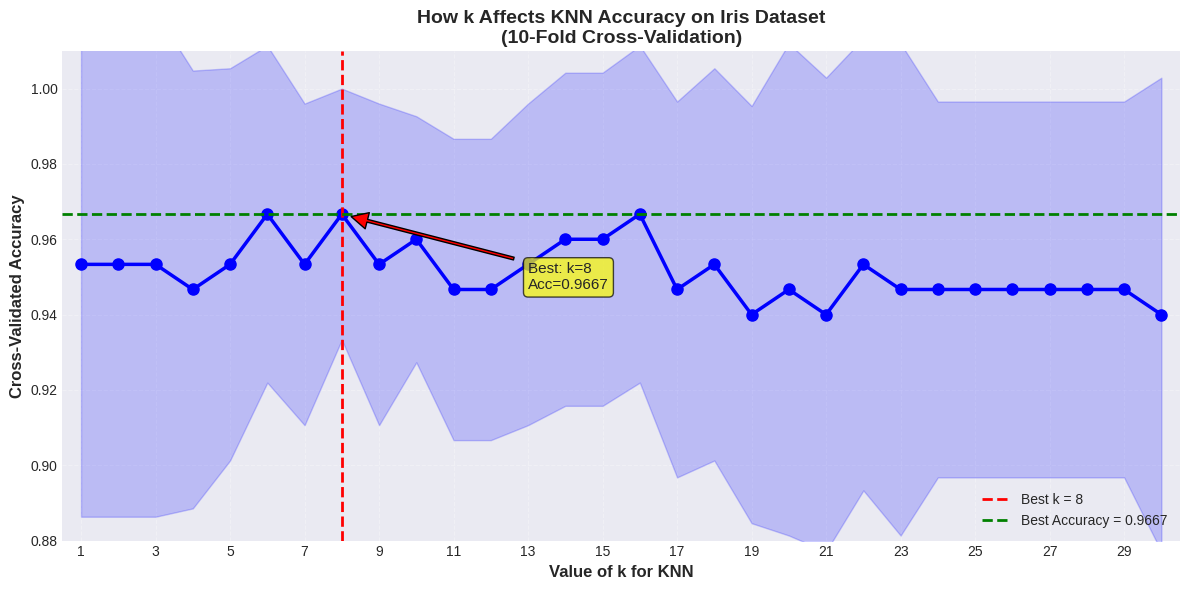

In [13]:
print(" Creating first graph: Accuracy vs k value")

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting the accuracy curve
ax.plot(k_range, cv_scores, 'b-', linewidth=2.5, marker='o', markersize=8)

# Adding shaded region for standard deviation
ax.fill_between(k_range,
                 np.array(cv_scores) - np.array(cv_scores_std),
                 np.array(cv_scores) + np.array(cv_scores_std),
                 alpha=0.2, color='b')

# Marking the optimal k
ax.axvline(x=optimal_k, color='red', linestyle='--', linewidth=2,
           label=f'Best k = {optimal_k}')
ax.axhline(y=optimal_accuracy, color='green', linestyle='--', linewidth=2,
           label=f'Best Accuracy = {optimal_accuracy:.4f}')

# Customize the plot
ax.set_xlabel('Value of k for KNN', fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validated Accuracy', fontsize=12, fontweight='bold')
ax.set_title('How k Affects KNN Accuracy on Iris Dataset\n(10-Fold Cross-Validation)',
             fontsize=14, fontweight='bold')

ax.set_xlim(0.5, 30.5)
ax.set_ylim(0.88, 1.01)
ax.set_xticks(list(k_range)[::2])
ax.grid(True, alpha=0.3, linestyle='--')

# Adding annotation for the best point
ax.annotate(f'Best: k={optimal_k}\nAcc={optimal_accuracy:.4f}',
            xy=(optimal_k, optimal_accuracy),
            xytext=(optimal_k+5, optimal_accuracy-0.02),
            arrowprops=dict(facecolor='red', shrink=0.05, width=2),
            fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


Creating second graph: Accuracy with Standard Deviation


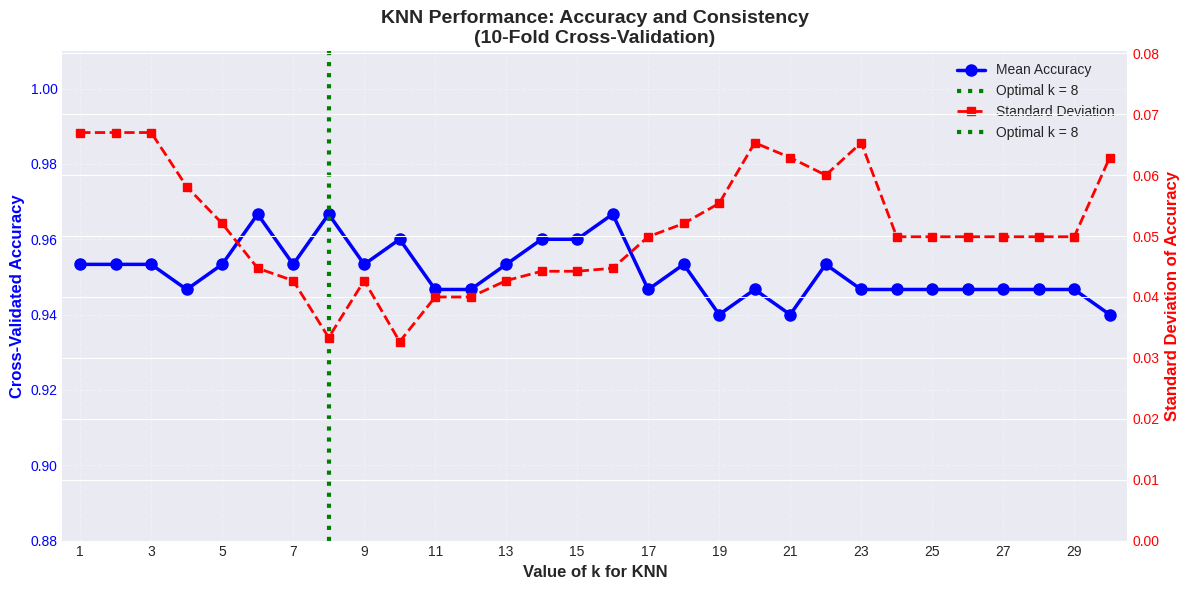

In [14]:
print("Creating second graph: Accuracy with Standard Deviation")

fig, ax = plt.subplots(figsize=(12, 6))

# Plotting mean accuracy (left y-axis)
color_acc = 'blue'
ax.plot(k_range, cv_scores, color=color_acc, linewidth=2.5,
        marker='o', markersize=8, label='Mean Accuracy')
ax.set_xlabel('Value of k for KNN', fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validated Accuracy', fontsize=12, fontweight='bold',
              color=color_acc)
ax.tick_params(axis='y', labelcolor=color_acc)
ax.set_xlim(0.5, 30.5)
ax.set_ylim(0.88, 1.01)
ax.set_xticks(list(k_range)[::2])
ax.grid(True, alpha=0.3, linestyle='--')

# Creating second y-axis for standard deviation
ax_std = ax.twinx()
color_std = 'red'
ax_std.plot(k_range, cv_scores_std, color=color_std, linestyle='--',
            linewidth=2, marker='s', markersize=6, label='Standard Deviation')
ax_std.set_ylabel('Standard Deviation of Accuracy', fontsize=12,
                  fontweight='bold', color=color_std)
ax_std.tick_params(axis='y', labelcolor=color_std)
ax_std.set_ylim(0, max(cv_scores_std) * 1.2)

# Marking optimal k
ax.axvline(x=optimal_k, color='green', linestyle=':', linewidth=3,
           label=f'Optimal k = {optimal_k}')


lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_std.get_legend_handles_labels()
ax.legend(lines1 + lines2 + [ax.lines[-1]],
          labels1 + labels2 + [f'Optimal k = {optimal_k}'],
          loc='upper right')

ax.set_title('KNN Performance: Accuracy and Consistency\n(10-Fold Cross-Validation)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


Confirmation with GridSearchCV

In [15]:
# Setting up the parameter grid
param_grid = {'n_neighbors': list(range(1, 31))}

# Creating KNN classifier
knn = KNeighborsClassifier()

# Setting up GridSearch with 10-fold cross-validation
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=10,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)


grid_search.fit(X_scaled, y)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best accuracy: {grid_search.best_score_:.4f}")
print()

# Showing detailed results
results = pd.DataFrame(grid_search.cv_results_)
top_results = results[['param_n_neighbors', 'mean_test_score', 'std_test_score']]
top_results = top_results.sort_values('mean_test_score', ascending=False).head(10)
display(top_results)

Best parameters: {'n_neighbors': 8}
Best accuracy: 0.9667



,param_n_neighbors,mean_test_score,std_test_score
7,8,0.966667,0.033333
5,6,0.966667,0.044721
15,16,0.966667,0.044721
9,10,0.960000,0.032660
14,15,0.960000,0.044222
13,14,0.960000,0.044222
8,9,0.953333,0.042687
4,5,0.953333,0.052068
2,3,0.953333,0.066999
6,7,0.953333,0.042687


Plotting GridSearchCV results...


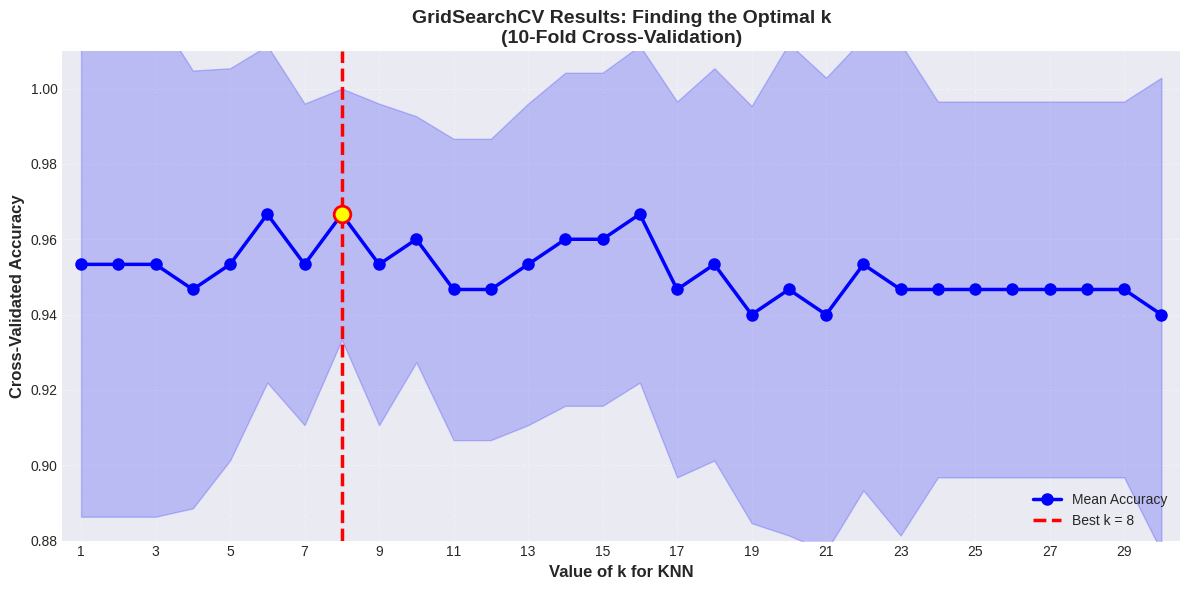

   Confirmed: k = 8 gives the best accuracy of 0.9667


In [16]:
print("Plotting GridSearchCV results...")

fig, ax = plt.subplots(figsize=(12, 6))

# Extract results
k_values = results['param_n_neighbors']
mean_scores = results['mean_test_score']
std_scores = results['std_test_score']

# Plot mean scores
ax.plot(k_values, mean_scores, 'b-', linewidth=2.5, marker='o',
        markersize=8, label='Mean Accuracy')

# Add error bars for standard deviation
ax.fill_between(k_values,
                 mean_scores - std_scores,
                 mean_scores + std_scores,
                 alpha=0.2, color='b')

# Mark the best k
best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=2.5,
           label=f'Best k = {best_k}')

# Customize plot
ax.set_xlabel('Value of k for KNN', fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validated Accuracy', fontsize=12, fontweight='bold')
ax.set_title('GridSearchCV Results: Finding the Optimal k\n(10-Fold Cross-Validation)',
             fontsize=14, fontweight='bold')

ax.set_xlim(0.5, 30.5)
ax.set_ylim(0.88, 1.01)
ax.set_xticks(list(range(1, 31))[::2])
ax.grid(True, alpha=0.3, linestyle='--')

# Highlighting the best point
ax.plot(best_k, best_score, 'ro', markersize=12,
        markerfacecolor='yellow', markeredgewidth=2)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"   Confirmed: k = {best_k} gives the best accuracy of {best_score:.4f}")

Final Model Evaluation with Optimal k



Training final model with optimal k...
Optimal k: 8
Cross-validation scores: [1.         0.93333333 1.         0.93333333 1.         1.
 0.93333333 0.93333333 1.         0.93333333]
Mean accuracy: 0.9667
Standard deviation: 0.0333
Accuracy range: [0.9333, 1.0000]


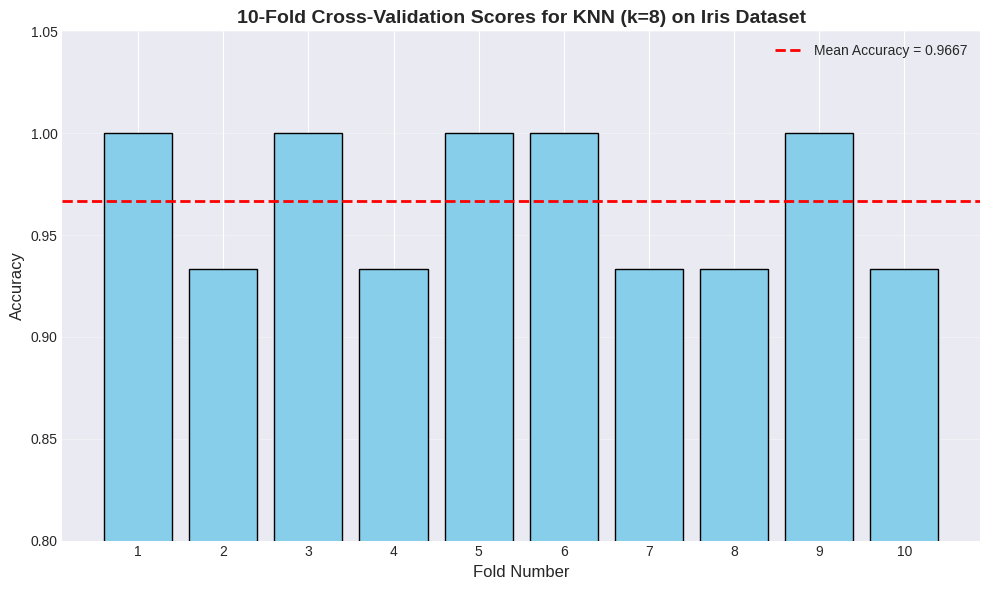

In [17]:
# Training final model with optimal k
print("\nTraining final model with optimal k...")
optimal_k = grid_search.best_params_['n_neighbors']
final_knn = KNeighborsClassifier(n_neighbors=optimal_k)

# Performing final cross-validation
final_scores = cross_val_score(final_knn, X_scaled, y, cv=10, scoring='accuracy')
print(f"Optimal k: {optimal_k}")
print(f"Cross-validation scores: {final_scores}")
print(f"Mean accuracy: {final_scores.mean():.4f}")
print(f"Standard deviation: {final_scores.std():.4f}")
print(f"Accuracy range: [{final_scores.min():.4f}, {final_scores.max():.4f}]")

# Visualizing cross-validation scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 11), final_scores, color='skyblue', edgecolor='black')
plt.axhline(y=final_scores.mean(), color='r', linestyle='--', linewidth=2,
            label=f'Mean Accuracy = {final_scores.mean():.4f}')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'10-Fold Cross-Validation Scores for KNN (k={optimal_k}) on Iris Dataset',
          fontsize=14, fontweight='bold')
plt.ylim(0.8, 1.05)
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3, axis='y')
plt.legend(loc='best')
plt.tight_layout()
plt.show()